# Impulsive Mode Decomposition (IMD)

Python reimplementation of **IMD** (Hou, Xie, Yan & Wang, *Mechanical Systems and Signal Processing*, 211:111227, 2024).

Unlike general SDMs (EMD / VMD / EWT) whose assumed modes are not impulsive by construction, IMD is **specialised for pulse / pulse-train extraction**. It builds an **adaptive ideal filterbank** by maximising a geometrical-mean sparsity index (**GM2to1**) of the squared Hilbert envelope, and returns:

- **impulsive modes** — band-limited oscillatory pulses with sparse envelope energy;
- **residual (non-impulsive) modes** — the complementary frequency bands.

This notebook summarises the paper’s definition, core formulas, and search algorithm, then reproduces the MATLAB demo on packaged data.

## 1. Imports

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "imd":
    ROOT = ROOT.parent.parent
elif ROOT.name == "examples":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path and (ROOT / "pysdkit").exists():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

from pysdkit import IMD, imd
from pysdkit._imd.imd import (
    fre_am,
    fft_bandpass,
    load_imd_input_sig,
    load_imd_gearbox_snippet,
)

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})

## 2. Method principles (from the paper)

### 2.1 What is an impulsive mode?

The paper formally defines an **impulsive mode** as a component that

1. contains **one or several duration-limited oscillatory waveforms (pulses)** that live in the **same band-limited frequency support**;
2. has a Hilbert envelope whose **energy is sparsely concentrated** on those pulse durations (and nearly flat elsewhere).

Hence an impulsive mode has two structural features:

| Domain | Feature | Consequence |
| --- | --- | --- |
| Frequency | **band-limited** | can be recovered by a band-pass filter |
| Time | **sparse envelope energy** | sparsity measures can score candidate bands |

Pulses that occupy **different** frequency bands are treated as **different** impulsive modes. The IMD problem is therefore: *adaptively partition $[0,F_s/2]$ into informative passbands that maximise impulsiveness, plus residual bands.*

### 2.2 Squared envelope

For a candidate component $x=[x_1,\ldots,x_N]^\mathsf{T}$, form the analytic signal and the **squared envelope (SE)**

$$
\mathrm{SE}
=
\bigl|\,x + j\,\mathcal{H}(x)\,\bigr|^{2},
\qquad
\mathrm{SE}\in\mathbb{R}^{N}.
\tag{2}
$$

where $\mathcal{H}(\cdot)$ is the Hilbert transform. Squaring sharpens the tower-shaped envelope peaks and flattens non-impulsive regions, which improves sparsity quantification.

### 2.3 $pq$-mean sparsity score $M_{2\to 1}$

On a non-negative sequence $c=[c_1,\ldots,c_L]$ (here a SE segment), the classical $pq$-mean with $(p,q)=(2,1)$ is

$$
M_{2\to 1}(c)
=
\frac{\displaystyle\sqrt{\frac1L\sum_{n=1}^{L} c_n^{2}}}
{\displaystyle\frac1L\sum_{n=1}^{L} c_n}
=
\frac{\|c\|_2/\sqrt{L}}{\|c\|_1/L}.
\tag{3}
$$

Larger $M_{2\to 1}$ means a sparser sequence. The paper prefers this index because:

- it satisfies the six desirable sparsity attributes of Hurley & Rickard;
- it is equivalent (up to scaling) to a revised $L_2/L_1$ ratio closely related to **kurtosis**, but cheaper;
- it remains sensitive at high sparsity (low SNR).

**Property (theoretical floor).** $M_{2\to 1}\ge 1$. For the SE of Gaussian white noise one has $M_{2\to 1}\to\sqrt{2}$; for a pure sinusoid or a constant, $M_{2\to 1}=1$.

### 2.4 Geometrical mean–based $pq$-mean (GM2to1)

A single strong pulse is *sparser* than a whole pulse train of the same length, so raw $M_{2\to 1}$ would bias the optimiser toward one spike. To balance **single-pulse** vs **cyclic train** extraction, the SE is split into $S$ non-overlapping segments $\mathrm{SE}^{(1)},\ldots,\mathrm{SE}^{(S)}$ of length $\ell=\lfloor N/S\rfloor$, and the scores are aggregated by a **geometric mean**:

$$
\mathrm{GM}_{2\to 1}(\mathrm{SE})
=
\Biggl(\prod_{i=1}^{S}
M_{2\to 1}\bigl(\mathrm{SE}^{(i)}\bigr)
\Biggr)^{1/S}.
\tag{4}
$$

- $S=1$ → prefer a **single** impulsive event;
- $S$ moderately large but smaller than the expected pulse count $J$ → prefer a **train**.

In rotating-machinery settings one may estimate $J\approx f_{\mathrm{cf}}T_s$ from a characteristic fault frequency $f_{\mathrm{cf}}$ and record length $T_s$.

> **Remark (implementation).** The shipped MATLAB toolbox evaluates a numerically related **CESM** form
> $\bigl(\tfrac1S\sum_i (M_p/M_q)_i^{\,a}\bigr)^{1/a}$ with $(p,q,a)=(2,1,-10)$, which recovers the same GM2to1 spirit (order-$a$ mean of the per-segment $M_{2\to 1}$ ratios). PySDKit follows that toolbox default.

### 2.5 Ideal FFT band-pass filter

For cut-offs $0\le f_L<f_H\le F_s/2$, IMD uses an **ideal** band-pass realised in the DFT domain (no FIR/IIR delay or gain ambiguity):

$$
Y[k]=\begin{cases}
X[k], & f_k\in[f_L,f_H]\ \cup\ [F_s-f_H,\,F_s-f_L],\\
0, & \text{otherwise},
\end{cases}
\qquad
y=\mathcal{F}^{-1}\{Y\}.
$$

Each PSO particle is exactly the pair $(f_L,f_H)$ inside a search interval $[f_{RL},f_{RH}]$.

### 2.6 Optimisation statement for one mode

Inside a candidate interval $[f_{RL},f_{RH}]$, IMD solves

$$
(f_L^\star,f_H^\star)
=
\arg\max_{f_{RL}\le f_L<f_H\le f_{RH}}
\;
\mathrm{GM}_{2\to 1}\!\Bigl(
\mathrm{SE}\bigl(
\mathrm{BP}_{[f_L,f_H]}(x)
\bigr)
\Bigr),
$$

with **PSO** ($N_2$ particles, $N_3$ iterations). The attained fitness is denoted $\mathrm{GM}_{\max}$.

### 2.7 Iterative adaptive filterbank (full IMD)

Hyper-parameters: PSO sizes $(N_2,N_3)$, segment count $S$, acceptance threshold $T$, max modes $N_4$.

1. **First search** on $[0,F_s/2]$ → $(f_L,f_H,\mathrm{GM}_{\max})$.
2. If $\mathrm{GM}_{\max}<T$, stop (no sufficiently impulsive mode). Otherwise store the band in the informative set $\mathcal{I}$ and push leftover intervals into a candidate queue $\mathcal{C}$ via band splitting.
3. **While** $\mathcal{C}\neq\emptyset$ and $|\mathcal{I}|<N_4$: search the first candidate; accept into $\mathcal{I}$ only if $\mathrm{GM}_{\max}\ge T$, and enqueue newly split leftovers.
4. **Residual bands** = complement of $\mathcal{I}$ inside $[0,F_s/2]$.
5. **Modes** = ideal band-pass reconstructions of every band in $\mathcal{I}$ (and optionally of residual bands).

Band splitting (Algorithm 2) keeps a leftover piece only when its width exceeds a minimum bandwidth $B_{\min}$:

$$
\mathcal{C}\leftarrow
\bigl\{[f_{RL},f_L]\,:\,f_L-f_{RL}>B_{\min}\bigr\}
\cup
\bigl\{[f_H,f_{RH}]\,:\,f_{RH}-f_H>B_{\min}\bigr\}.
$$

Informative bands are finally sorted by descending $\mathrm{GM}_{\max}$ for display / diagnosis.

### 2.8 Why not MED / kurtogram / VMD?

| Method | Main issue for impulsive extraction |
| --- | --- |
| Kurtogram | fixed filterbank; typically returns **one** band |
| MED / blind deconvolution | FIR delay, amplitude scaling, hard to iterate residuals |
| VMD / EWT | modes are not defined as impulsive; weak pulses may be missed or fractured |

IMD avoids delay/scaling by using an ideal DFT filter, extracts **multiple** modes by successive band search, and scores bands with GM2to1 so both single pulses and trains are controllable via $S$.

## 3. Packaged MATLAB demo — `InputSig`

Compound-fault example from the authors’ script `AA_Example_IMD.m`
(MCC5-THU gearbox: bearing outer-race + gear fault, $F_s=12.8\,\mathrm{kHz}$, 2 s).
Data are shipped as `pysdkit/_imd/data/input_sig.npy`.

Typical MATLAB-style settings: `threshold`$\,=\,T=1.60$, `seg_num`$\,=\,S=10$,
`max_modes`$\,=\,N_4=4$, PSO (`n_particles`, `max_iter`) $\leftrightarrow (N_2,N_3)$.

N=25600, Fs=12800 Hz, duration=2.00 s


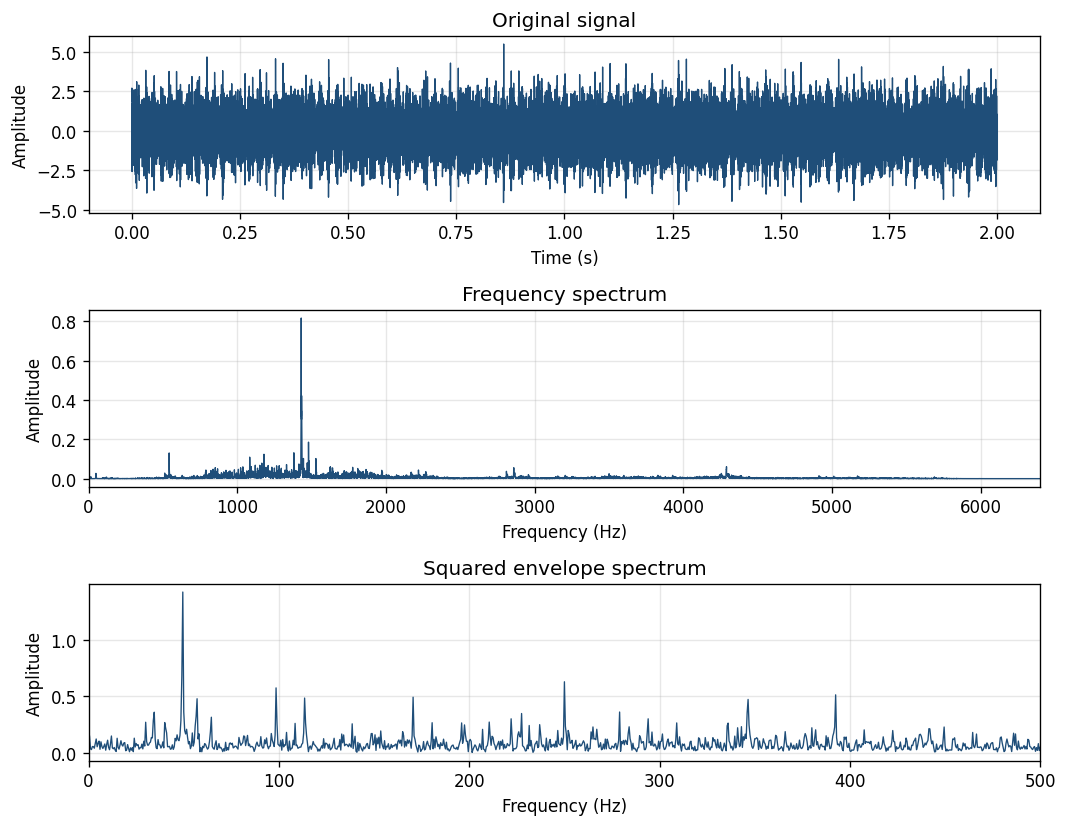

In [2]:
demo = load_imd_input_sig()
x, fs, t = demo["signal"], float(demo["fs"]), demo["t"]
print(f"N={x.size}, Fs={fs:.0f} Hz, duration={t[-1]:.2f} s")

fig, axes = plt.subplots(3, 1, figsize=(9, 7))
axes[0].plot(t, x, color="#1f4e79", lw=0.8)
axes[0].set_ylabel("Amplitude")
axes[0].set_xlabel("Time (s)")
axes[0].set_title("Original signal")

f, a = fre_am(x, fs)
axes[1].plot(f, a, color="#1f4e79", lw=0.8)
axes[1].set_xlim(0, fs / 2)
axes[1].set_ylabel("Amplitude")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_title("Frequency spectrum")

se = np.abs(hilbert(x)) ** 2
f2, a2 = fre_am(se, fs)
axes[2].plot(f2[1:], a2[1:], color="#1f4e79", lw=0.8)
axes[2].set_xlim(0, 500)
axes[2].set_ylabel("Amplitude")
axes[2].set_xlabel("Frequency (Hz)")
axes[2].set_title("Squared envelope spectrum")
plt.tight_layout()
plt.show()

Selected bands [f_low, f_high, fitness]:
[[   0.    1352.447    1.68 ]
 [3146.412 3805.118    1.666]]
modes shape: (2, 25600)


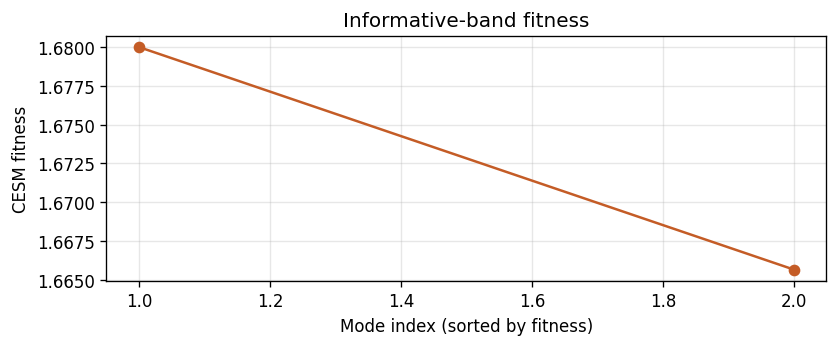

In [3]:
# Parameters aligned with AA_Example_IMD.m
# (PSO cost ~ n_particles * max_iter * FFT; seed for reproducibility)
decomp = IMD(
    n_particles=30,
    max_iter=12,
    threshold=1.60,
    min_band=0.0,
    max_modes=4,
    seg_num=10,
    seed=0,
)
out = decomp.fit_transform(x, fs=fs, return_all=True)
modes = out["modes"]
bands = out["selected_bands"]

print("Selected bands [f_low, f_high, fitness]:")
print(np.array2string(bands, precision=3, suppress_small=True))
print("modes shape:", modes.shape)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(np.arange(1, bands.shape[0] + 1), bands[:, 2], "o-", color="#c45c26")
ax.set_xlabel("Mode index (sorted by fitness)")
ax.set_ylabel("CESM fitness")
ax.set_title("Informative-band fitness")
plt.tight_layout()
plt.show()

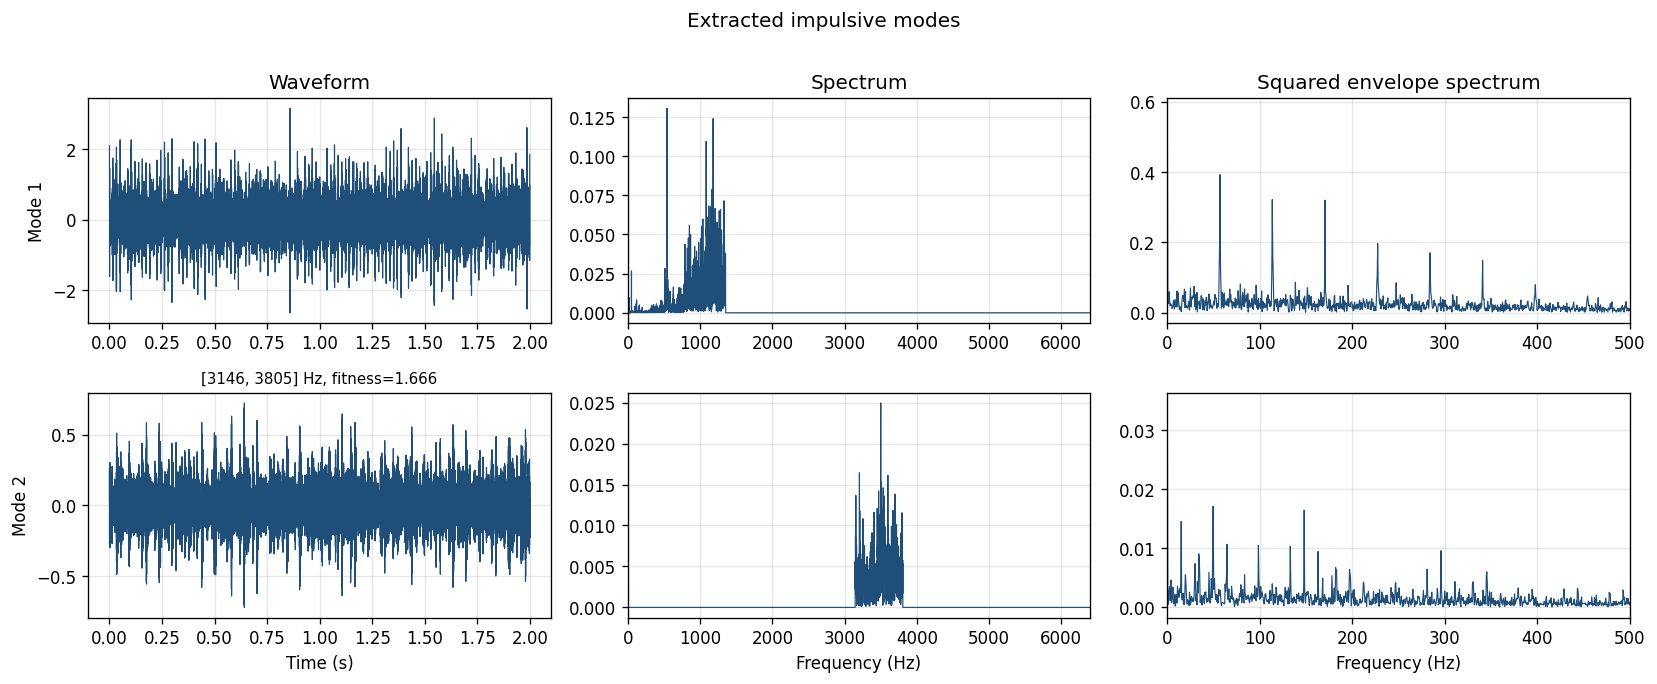

In [4]:
# MATLAB-style panels: waveform / spectrum / SES for each impulsive mode
n_modes = modes.shape[0]
fig, axes = plt.subplots(n_modes, 3, figsize=(14, 2.8 * n_modes), squeeze=False)
for i in range(n_modes):
    mi = modes[i]
    axes[i, 0].plot(t, mi, color="#1f4e79", lw=0.7)
    axes[i, 0].set_ylabel(f"Mode {i+1}")
    if i == n_modes - 1:
        axes[i, 0].set_xlabel("Time (s)")

    f1, a1 = fre_am(mi, fs)
    axes[i, 1].plot(f1, a1, color="#1f4e79", lw=0.7)
    axes[i, 1].set_xlim(0, fs / 2)
    if i == n_modes - 1:
        axes[i, 1].set_xlabel("Frequency (Hz)")

    f3, a3 = fre_am(np.abs(hilbert(mi)) ** 2, fs)
    axes[i, 2].plot(f3, a3, color="#1f4e79", lw=0.7)
    axes[i, 2].set_xlim(0, 500)
    if i == n_modes - 1:
        axes[i, 2].set_xlabel("Frequency (Hz)")

    fl, fh, fit = bands[i]
    axes[i, 0].set_title(f"[{fl:.0f}, {fh:.0f}] Hz, fitness={fit:.3f}", fontsize=9)

axes[0, 0].set_title("Waveform")
axes[0, 1].set_title("Spectrum")
axes[0, 2].set_title("Squared envelope spectrum")
fig.suptitle("Extracted impulsive modes", y=1.01)
plt.tight_layout()
plt.show()

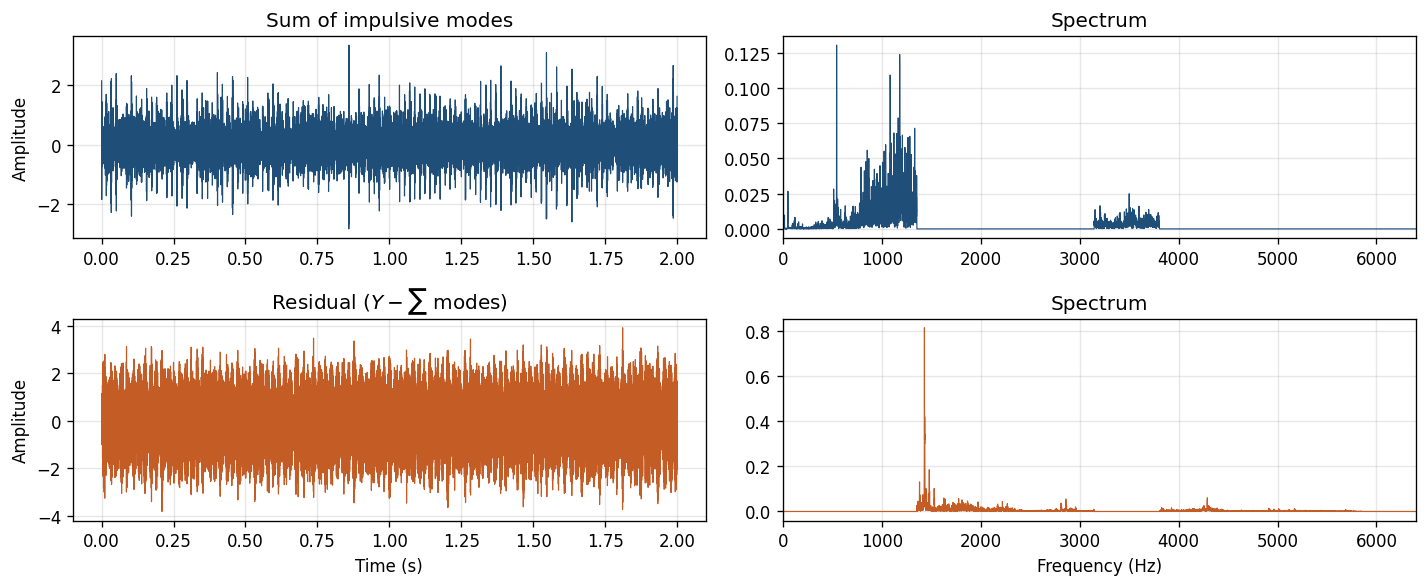

residual bands:
 [[1352.44654076 3146.4123298 ]
 [3805.11784288 6400.        ]]


In [5]:
# Mixed IMDs vs residual
sum_modes = modes.sum(axis=0)
residual = out["residual"]

fig, axes = plt.subplots(2, 2, figsize=(12, 5))
axes[0, 0].plot(t, sum_modes, color="#1f4e79", lw=0.7)
axes[0, 0].set_title("Sum of impulsive modes")
axes[0, 0].set_ylabel("Amplitude")
f, a = fre_am(sum_modes, fs)
axes[0, 1].plot(f, a, color="#1f4e79", lw=0.7)
axes[0, 1].set_xlim(0, fs / 2)
axes[0, 1].set_title("Spectrum")

axes[1, 0].plot(t, residual, color="#c45c26", lw=0.7)
axes[1, 0].set_title("Residual ($Y - \sum$ modes)")
axes[1, 0].set_xlabel("Time (s)")
axes[1, 0].set_ylabel("Amplitude")
f, a = fre_am(residual, fs)
axes[1, 1].plot(f, a, color="#c45c26", lw=0.7)
axes[1, 1].set_xlim(0, fs / 2)
axes[1, 1].set_xlabel("Frequency (Hz)")
axes[1, 1].set_title("Spectrum")
plt.tight_layout()
plt.show()

print("residual bands:\n", out["residual_bands"])

## 4. Packaged CSV snippet

The original CSV
`teeth_break_and_bearing_outer_H_torque_circulation_3000rpm_20Nm.csv`
is very large (~768k rows). A short excerpt of
`gearbox_vibration_x` (first 4096 samples, $F_s=12.8\,\mathrm{kHz}$) is stored as
`pysdkit/_imd/data/gearbox_fault_snippet.npy` and ships with the package.

This section only illustrates the same IMD workflow on a shorter industrial snippet; interpret bands with care because the record is much shorter than the full 2 s `InputSig` demo.

snippet N=4096, duration=0.320 s
bands:
 [[0.00e+00 2.77e+03 1.42e+00]
 [2.77e+03 3.96e+03 1.41e+00]
 [3.96e+03 4.60e+03 1.41e+00]]


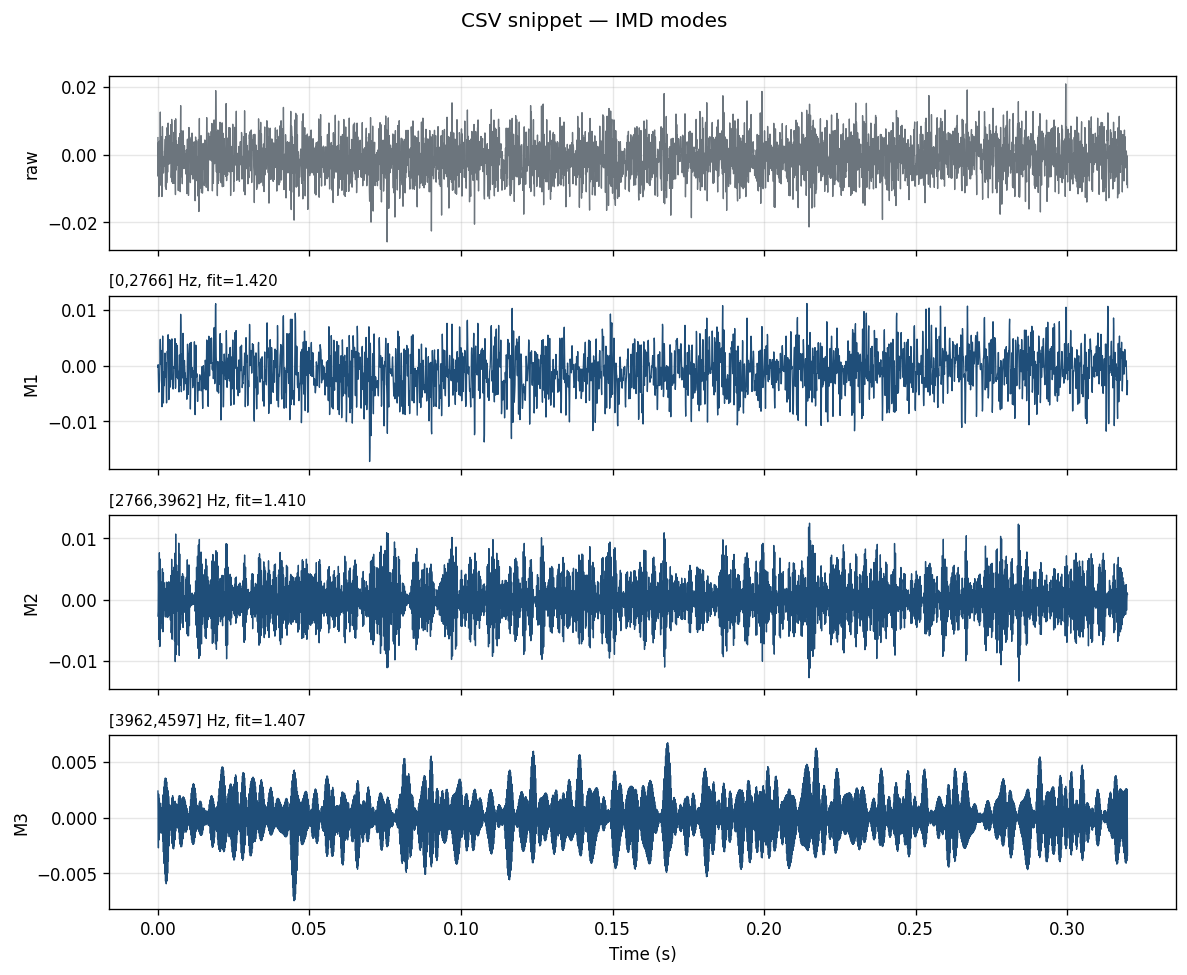

In [6]:
snip = load_imd_gearbox_snippet()
xs, fss, ts = snip["signal"], float(snip["fs"]), snip["t"]
print(f"snippet N={xs.size}, duration={ts[-1]:.3f} s")

imd_s = IMD(
    n_particles=25,
    max_iter=10,
    threshold=1.30,
    max_modes=3,
    seg_num=8,
    seed=0,
)
out_s = imd_s.fit_transform(xs, fs=fss, return_all=True)
print("bands:\n", np.array2string(out_s["selected_bands"], precision=2))

fig, axes = plt.subplots(out_s["modes"].shape[0] + 1, 1, figsize=(10, 8), sharex=True)
axes[0].plot(ts, xs, color="#6c757d", lw=0.8)
axes[0].set_ylabel("raw")
for i, m in enumerate(out_s["modes"]):
    axes[i + 1].plot(ts, m, color="#1f4e79", lw=0.8)
    fl, fh, fit = out_s["selected_bands"][i]
    axes[i + 1].set_ylabel(f"M{i+1}")
    axes[i + 1].set_title(
        f"[{fl:.0f},{fh:.0f}] Hz, fit={fit:.3f}", fontsize=9, loc="left"
    )
axes[-1].set_xlabel("Time (s)")
fig.suptitle("CSV snippet — IMD modes", y=1.01)
plt.tight_layout()
plt.show()

## 5. Functional API

In [7]:
modes_fn = imd(
    xs,
    fs=fss,
    n_particles=15,
    max_iter=6,
    threshold=1.30,
    max_modes=2,
    seg_num=8,
    seed=1,
)
print("functional API shape:", modes_fn.shape)

functional API shape: (2, 4096)


## References

1. B. Hou, M. Xie, H. Yan, D. Wang. *Impulsive mode decomposition.* Mechanical Systems and Signal Processing, **211**:111227, 2024. https://doi.org/10.1016/j.ymssp.2024.111227  
   (definition of impulsive mode; GM2to1 / Eqs. (2)–(4); Algorithms 1–2 / adaptive filterbank)
2. B. Hou et al. *Cycle-embedded sparsity measures as a generalized objective function of impulsive mode decomposition...* MSSP, **231**:112566, 2025.  
   (CESM generalisation used in the MATLAB toolbox objective)